In [5]:
from typing import Union
import pandas as pd


def accuracy(y_hat: pd.Series, y: pd.Series) -> float:
    """
    Function to calculate the accuracy
    """
    assert isinstance(y_hat, pd.Series)
    assert isinstance(y, pd.Series)
    assert y_hat.size == y.size, "y_hat and y must be of same length"
    assert y_hat.size > 0, "y_hat and y must be non-empty"

    return (y_hat == y).sum() / y_hat.size

def precision(y_hat: pd.Series, y: pd.Series, cls: Union[int, str]) -> float:
    """
    Function to calculate the precision for a given class `cls`
    """
    assert isinstance(y_hat, pd.Series)
    assert isinstance(y, pd.Series)
    assert y_hat.size == y.size, "y_hat and y must be of same length"
    assert y_hat.size > 0, "y_hat and y must be non-empty"

    # Positive predictions = predicted cls
    pred_pos = (y_hat == cls)
    true_pos = (y == cls)

    TP = (pred_pos & true_pos).sum()
    FP = (pred_pos & ~true_pos).sum()

    if TP + FP == 0:
        # No predictions for this class
        return 0.0

    return TP / (TP + FP)


def recall(y_hat: pd.Series, y: pd.Series, cls: Union[int, str]) -> float:
    """
    Function to calculate the recall for a given class `cls`
    """
    assert isinstance(y_hat, pd.Series)
    assert isinstance(y, pd.Series)
    assert y_hat.size == y.size, "y_hat and y must be of same length"
    assert y_hat.size > 0, "y_hat and y must be non-empty"

    pred_pos = (y_hat == cls)
    true_pos = (y == cls)

    TP = (pred_pos & true_pos).sum()
    FN = (~pred_pos & true_pos).sum()

    if TP + FN == 0:
        # Class `cls` never appears in true labels
        return 0.0

    return TP / (TP + FN)



def rmse(y_hat: pd.Series, y: pd.Series) -> float:
    """
    Function to calculate the root-mean-squared-error(rmse)
    """
    assert isinstance(y_hat, pd.Series)
    assert isinstance(y, pd.Series)
    assert y_hat.size == y.size, "y_hat and y must be of same length"
    assert y_hat.size > 0, "y_hat and y must be non-empty"

    diff = y_hat - y
    mse = (diff ** 2).mean()
    return mse ** 0.5


def mae(y_hat: pd.Series, y: pd.Series) -> float:
    """
    Function to calculate the mean-absolute-error(mae)
    """
    assert isinstance(y_hat, pd.Series)
    assert isinstance(y, pd.Series)
    assert y_hat.size == y.size, "y_hat and y must be of same length"
    assert y_hat.size > 0, "y_hat and y must be non-empty"

    return (y_hat - y).abs().mean()


In [6]:
import pandas as pd
import math


def one_hot_encoding(X: pd.DataFrame) -> pd.DataFrame:
    """
    Function to perform one hot encoding on the input data.
    Converts categorical (object/category) columns to 0/1 columns.
    Numeric columns are left as-is.
    """
    assert isinstance(X, pd.DataFrame), "X must be a pandas DataFrame"
    # drop_first=False -> keep all categories (no need to drop because trees don't care about collinearity)
    X_enc = pd.get_dummies(X, drop_first=False)
    return X_enc


def check_ifreal(y: pd.Series) -> bool:
    """
    Function to check if the given series has real (continuous) or discrete values.
    Here we treat float-dtype targets as real-valued.
    """
    assert isinstance(y, pd.Series), "y must be a pandas Series"
    return pd.api.types.is_float_dtype(y)



def entropy(Y: pd.Series) -> float:
    """
    Function to calculate the entropy of a discrete label Series Y.
    """
    assert isinstance(Y, pd.Series), "Y must be a pandas Series"
    assert Y.size > 0, "Y must be non-empty"

    # Probability of each class
    probs = Y.value_counts(normalize=True)

    ent = 0.0
    for p in probs:
        if p > 0:
            ent -= p * math.log2(p)
    return ent



def gini_index(Y: pd.Series) -> float:
    """
    Function to calculate the gini index of a discrete label Series Y.
    """
    assert isinstance(Y, pd.Series), "Y must be a pandas Series"
    assert Y.size > 0, "Y must be non-empty"

    probs = Y.value_counts(normalize=True)
    return 1.0 - (probs ** 2).sum()


def information_gain(Y: pd.Series, attr: pd.Series, criterion: str) -> float:
    """
    Function to calculate the information gain using criterion 
    (entropy, gini index, or MSE) when splitting Y using attribute 'attr'.
    """
    assert isinstance(Y, pd.Series)
    assert isinstance(attr, pd.Series)
    assert Y.size == attr.size, "Y and attr must have same length"
    assert Y.size > 0, "Y must be non-empty"

    N = Y.size

    def mse(values: pd.Series) -> float:
        mean_val = values.mean()
        return ((values - mean_val) ** 2).mean()

    # parent impurity
    if criterion == "entropy":
        parent_imp = entropy(Y)
        impurity_func = entropy
    elif criterion == "gini":
        parent_imp = gini_index(Y)
        impurity_func = gini_index
    elif criterion.lower() == "mse":
        parent_imp = mse(Y)
        impurity_func = mse
    else:
        raise ValueError(f"Unknown criterion: {criterion}")

    # weighted impurity of children
    df = pd.DataFrame({"Y": Y, "A": attr})
    weighted_impurity = 0.0

    for _, group in df.groupby("A"):
        w = group.shape[0] / N
        weighted_impurity += w * impurity_func(group["Y"])

    return parent_imp - weighted_impurity


def opt_split_attribute(X: pd.DataFrame, y: pd.Series, criterion, features: pd.Series):
    """
    Function to find the optimal attribute to split about.

    features: pd.Series or list-like of column names we have to split upon

    return: attribute (column name) to split upon
    """

    assert isinstance(X, pd.DataFrame), "X must be a pandas DataFrame"
    assert isinstance(y, pd.Series), "y must be a pandas Series"
    assert X.shape[0] == y.size, "X and y must have the same number of rows"
    assert len(features) > 0, "features must be non-empty"

    best_attr = None
    best_gain = -float("inf")

    # Loop over all candidate features
    for attr in features:
        # attr is the column name
        col = X[attr]

        # Compute information gain for this feature
        gain = information_gain(y, col, criterion)

        # Keep track of the best one
        if gain > best_gain:
            best_gain = gain
            best_attr = attr

    return best_attr


def split_data(X: pd.DataFrame, y: pd.Series, attribute, value):
    """
    Function to split the data according to an attribute and a threshold.

    attribute: column name to split upon
    value: threshold value (for real features) or split value

    return: (X_left, y_left, X_right, y_right)
    """
    assert isinstance(X, pd.DataFrame)
    assert isinstance(y, pd.Series)
    assert attribute in X.columns, "attribute must be a column in X"
    assert X.shape[0] == y.size, "X and y must have same number of rows"

    col = X[attribute]
    left_mask = col <= value
    right_mask = ~left_mask

    X_left = X[left_mask]
    y_left = y[left_mask]

    X_right = X[right_mask]
    y_right = y[right_mask]

    return X_left, y_left, X_right, y_right


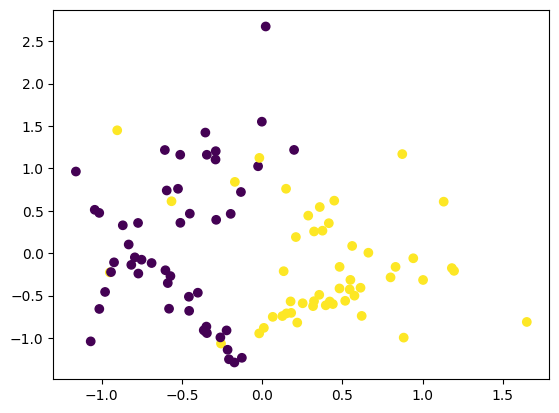

In [7]:
from sklearn.datasets import make_classification
X, y = make_classification(
n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=2, class_sep=0.5)

# For plotting
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y)

In [9]:
"""
The current code given is for the Assignment 1.
You will be expected to use this to make trees for:
> discrete input, discrete output
> real input, real output
> real input, discrete output
> discrete input, real output
"""
from dataclasses import dataclass
from typing import Literal, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from tree.utils import *

np.random.seed(42)


class _Node:
    """
    Internal class representing a node in the decision tree.
    """

    def __init__(
        self,
        is_leaf: bool = False,
        prediction=None,
        feature: Optional[str] = None,
        threshold: Optional[float] = None,
        left: Optional["_Node"] = None,
        right: Optional["_Node"] = None,
    ):
        self.is_leaf = is_leaf
        self.prediction = prediction
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right


@dataclass
class DecisionTree:
    criterion: Literal["information_gain", "gini_index"]  # criterion won't be used for regression
    max_depth: int  # The maximum depth the tree can grow to

    def __init__(self, criterion, max_depth=5):
        self.criterion = criterion
        self.max_depth = max_depth
        self.root: Optional[_Node] = None
        self.is_regression: Optional[bool] = None
        self.feature_names = None  # will store column order after encoding

    # ---------- PUBLIC API ----------

    def fit(self, X: pd.DataFrame, y: pd.Series) -> None:
        """
        Function to train and construct the decision tree.
        """

        assert isinstance(X, pd.DataFrame), "X must be a pandas DataFrame"
        assert isinstance(y, pd.Series), "y must be a pandas Series"
        assert X.shape[0] == y.size, "X and y must have same number of rows"
        assert self.max_depth >= 0, "max_depth must be non-negative"

        # Handle discrete input: one-hot encode
        X_enc = one_hot_encoding(X.copy())
        self.feature_names = list(X_enc.columns)

        # Decide if this is regression or classification based on y
        self.is_regression = check_ifreal(y)

        # Build the tree recursively
        self.root = self._build_tree(X_enc, y, depth=0)

    def predict(self, X: pd.DataFrame) -> pd.Series:
        """
        Function to run the decision tree on test inputs.
        """

        assert self.root is not None, "You must call fit() before predict()"
        assert isinstance(X, pd.DataFrame), "X must be a pandas DataFrame"

        # Apply the same encoding as during training
        X_enc = one_hot_encoding(X.copy())
        # Align columns with training columns (missing -> 0, extra -> drop)
        X_enc = X_enc.reindex(columns=self.feature_names, fill_value=0)

        preds = []
        for _, row in X_enc.iterrows():
            preds.append(self._predict_one(row))

        return pd.Series(preds, index=X.index)

    def plot(self) -> None:
        """
        Function to plot (print) the tree in a human-readable form.

        Output Example:
        ?(X1 > 4)
            Y: ?(X2 > 7)
                Y: Class A
                N: Class B
            N: Class C
        Where Y => Yes and N => No
        """
        assert self.root is not None, "You must call fit() before plot()"
        self._print_node(self.root, indent="")

    # ---------- INTERNAL METHODS ----------

    def _build_tree(self, X: pd.DataFrame, y: pd.Series, depth: int) -> _Node:
        """
        Recursively build the decision tree.
        """

        # Stopping conditions
        # 1. max depth reached
        if depth >= self.max_depth:
            return self._create_leaf(y)

        # 2. all labels same (pure node)
        if y.nunique() == 1:
            return self._create_leaf(y)

        # 3. no features left or no samples
        if X.shape[0] == 0 or X.shape[1] == 0:
            return self._create_leaf(y)

        # Choose criterion for utils (entropy/gini/mse)
        if self.is_regression:
            local_criterion = "mse"
        else:
            if self.criterion == "information_gain":
                local_criterion = "entropy"
            elif self.criterion == "gini_index":
                local_criterion = "gini"
            else:
                raise ValueError(f"Unknown criterion: {self.criterion}")

        # Candidate features to split on
        features = pd.Series(X.columns)

        # Find best attribute and threshold
        best_attr, best_thresh = opt_split_attribute(X, y, local_criterion, features)

        # If no useful split found, make a leaf
        if best_attr is None or best_thresh is None:
            return self._create_leaf(y)

        # Split the data
        X_left, y_left, X_right, y_right = split_data(X, y, best_attr, best_thresh)

        # If split fails (one side empty), make a leaf
        if X_left.shape[0] == 0 or X_right.shape[0] == 0:
            return self._create_leaf(y)

        # Recursively build children
        left_child = self._build_tree(X_left, y_left, depth + 1)
        right_child = self._build_tree(X_right, y_right, depth + 1)

        # Create internal node
        return _Node(
            is_leaf=False,
            prediction=None,
            feature=best_attr,
            threshold=best_thresh,
            left=left_child,
            right=right_child,
        )

    def _create_leaf(self, y: pd.Series) -> _Node:
        """
        Create a leaf node with the appropriate prediction.
        """
        if self.is_regression:
            # Regression -> predict mean
            pred = y.mean()
        else:
            # Classification -> predict majority class
            pred = y.value_counts().idxmax()

        return _Node(is_leaf=True, prediction=pred)

    def _predict_one(self, row: pd.Series):
        """
        Traverse the tree for a single example (one row) and return prediction.
        """
        node = self.root
        while not node.is_leaf:
            val = row[node.feature]
            if val <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.prediction

    def _print_node(self, node: _Node, indent: str) -> None:
        """
        Recursively print the tree.
        """
        if node.is_leaf:
            print(indent + f"Leaf: {node.prediction}")
            return

        # Internal node
        print(indent + f"?({node.feature} <= {node.threshold:.3f})")
        print(indent + "Y:")
        self._print_node(node.left, indent + "    ")
        print(indent + "N:")
        self._print_node(node.right, indent + "    ")


ModuleNotFoundError: No module named 'metrics'